# Exploración y Modelado
###### Sistema Actuarial de Precicción de Riesgo y Costo Esperado en seguros de automovil (SAPRICO) 
---

Se sugiere el uso de pipeline y column transformer

In [496]:
import numpy as np
import pandas as pd

from ipywidgets import interact, Dropdown, IntSlider, Checkbox, fixed
import seaborn as sns
import plotly.express as px


import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer

from sklearn.linear_model import LinearRegression, Lasso, Ridge

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.covariance import EllipticEnvelope

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


### 
from sklearn.ensemble import RandomForestRegressor 

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


### Carga del conjunto de datos

La base de datos sintetica es: `seguro_auto_actuarial.csv`

In [ ]:
data = pd.read_csv('../data/seguro_auto_actuarial.csv')

RANDOM_STATE = 42



In [498]:
## Se crea una funcion para podre pasarla a utils

# nbins es el número de intervalos que va a hacer en el continuo de los valores numericos

def histograma_plotly(data, variable_num, variable_cat, nbins = 40, por_cateogria = True):
    # Generamos el histograma con el marginal tipo box, pues esto hace posible ver los outliers mediante el método de IQR
    
    # Si queremos diferenciarlos por cateogrías
    if por_cateogria:
        fig = px.histogram(
            data,           
            x=variable_num, 
            color=variable_cat, # Diferenciar los datos por color mediante su categoría
            marginal="box",     # Agrega boxplot, o diagrama de caja y bigotes para ver el IQR  y por ende los outliers         
            barmode="overlay",  # Hace que se hagan menos opacos los histogrammas para verlos mejor         
            nbins= nbins,                     
            title=f"Distribución de {variable_num.replace('_', ' ').title()} por {variable_cat.replace('_', ' ').title()}",
            template="plotly_white",      # Un fondo blanco limpio y estético
            color_discrete_sequence=px.colors.qualitative.Safe # Paleta de colores moderna
        )

    # O bien, ver la distribución de la muestra para cada categoría numerica
    else: 
         fig = px.histogram(
            data, 
            x=variable_num, 
         
            marginal="box",               
            barmode="overlay",            
            nbins= nbins,                     
            title=f"Distribución de {variable_num.replace('_', ' ').title()}",
            template="plotly_white",      # Un fondo blanco limpio y estético
            color_discrete_sequence=px.colors.qualitative.Safe # Paleta de colores moderna       
        )
         
    fig.update_xaxes(title_text = variable_num.replace('_', ' ').title())
    fig.update_yaxes(title_text = 'Recuento')

    fig.update_layout(
    legend_title_text = variable_cat.replace('_', ' ').title(), 
    height=1000,
    title_font_size=18,
    hovermode="x unified"  # Agrupa el tooltip para ver todas las categorías juntas al pasar el mouse
    )
    fig.show()
    
    
def Balance_de_Clases(data, categoria):
    Conteo = data[categoria].value_counts().reset_index()
    Conteo.columns = ['Categoría', 'Cantidad']
    Conteo['Proporcion'] = Conteo['Cantidad']/Conteo['Cantidad'].sum().round(4)

    fig = px.bar(
        Conteo, 
        x = 'Categoría',
        y = 'Cantidad',
        text = Conteo['Proporcion'],
        title=f"Análisis de Balance de Clases de: {categoria.replace('_', ' ').title()}",
        template="plotly_white",
        color='Categoría',
        color_discrete_sequence=px.colors.qualitative.Pastel
    )

    fig.update_traces(textposition='outside') # Coloca el texto del % fuera de la barra
    fig.update_layout(
        yaxis_title="Número de Registros",
        xaxis_title=categoria.replace('_', ' ').title()
    )
    
    fig.show()   

In [499]:
# Interacción, transformación y discretización de variables
data['km_totales'] = data['km_anuales']*data['edad_vehiculo_anios']
data['log_km_totales'] = np.log(data['km_totales'])
data['log_ingreso_mensual_mxn'] = np.log(data['ingreso_mensual_mxn'])

data['prima_mayor_a_mediana'] = (data['prima_mensual_mxn'] > data['prima_mensual_mxn'].median()).astype(int) #True : 1 False : 0


In [500]:
tipos = {}

for i in data.dtypes.unique():
    tipos_key = str(i)
    columnas = data.select_dtypes(include = [i]).columns.tolist()
    tipos[tipos_key] = columnas


In [501]:
numerico = []

categorica = []

for j in tipos.keys():
   for i in tipos[j]:
      if(len(data[i].value_counts().index.to_list()) < 10):  ## cuantos valores unicos tiene
         categorica.append(i)

      else:
         numerico.append(i)
   
numerico.remove('poliza_id')

In [502]:
categorica

['sexo',
 'estado_civil',
 'nivel_estudios',
 'ocupacion',
 'zona_residencia',
 'region',
 'tipo_vehiculo',
 'uso_vehiculo',
 'segmento_marca',
 'metodo_pago',
 'canal_venta',
 'tiene_gps',
 'asistencia_vial',
 'mantenimiento_al_dia',
 'clase_costo',
 'deducible_pct',
 'historial_siniestros_3_anios',
 'numero_siniestros_12m',
 'riesgo_alto',
 'prima_mayor_a_mediana']

In [503]:
numerico

['edad_conductor',
 'dias_hasta_renovacion',
 'costo_esperado_anual_mxn',
 'antiguedad_cliente_anios',
 'ingreso_mensual_mxn',
 'score_crediticio',
 'prima_mensual_mxn',
 'suma_asegurada_mxn',
 'km_anuales',
 'edad_vehiculo_anios',
 'puntaje_riesgo_zona',
 'km_totales',
 'log_km_totales',
 'log_ingreso_mensual_mxn']

In [504]:

## Para hacer la separación de categórica en nominal, ordinal y binaria se hara un porceso
# iterativo y lugo pequeños ajustes a mano 


nominal = ['sexo','estado_civil', 'ocupacion', 'zona_residencia','region', 'tipo_vehiculo',
           'uso_vehiculo', 'metodo_pago', 'canal_venta']

ordinal = ['nivel_estudios','segmento_marca', 'clase_costo', 'deducible_pct', 'numero_siniestros_12m', 'historial_siniestros_3_anios']

binaria = ['tiene_gps','asistencia_vial','mantenimiento_al_dia']


In [505]:
orden_cateogrias = {}

for i in ordinal:
    orden_cateogrias[i] = list(data[i].unique())

orden_cateogrias



{'nivel_estudios': ['Posgrado', 'Licenciatura', 'Preparatoria', 'Secundaria'],
 'segmento_marca': ['Economico', 'Medio', 'Premium', nan],
 'clase_costo': ['Bajo', 'Medio', 'Alto'],
 'deducible_pct': [np.int64(5), np.int64(10), np.int64(15), np.int64(3)],
 'numero_siniestros_12m': [np.int64(0), np.int64(1), np.int64(2)],
 'historial_siniestros_3_anios': [np.int64(0),
  np.int64(2),
  np.int64(1),
  np.int64(3),
  np.int64(5)]}

In [506]:
orden_cateogrias = {

'nivel_estudios': ['Secundaria', 'Preparatoria', 'Licenciatura', 'Posgrado'],
 
 'segmento_marca': ['Economico', 'Medio', 'Premium'],
 
 'clase_costo': ['Bajo', 'Medio', 'Alto'],
 
 'deducible_pct': [np.int64(3), np.int64(5), np.int64(10), np.int64(15)],
 
 'numero_siniestros_12m': [np.int64(0), np.int64(1), np.int64(2)],
 
 'historial_siniestros_3_anios': [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5)]}

La base consta de las siguietenes  variables:

1. *Númericas*

`'edad_conductor',
 'dias_hasta_renovacion',
 'costo_esperado_anual_mxn',
 'antiguedad_cliente_anios',
 'ingreso_mensual_mxn',
 'score_crediticio',
 'prima_mensual_mxn',
 'suma_asegurada_mxn',
 'km_anuales',
 'edad_vehiculo_anios',
 'puntaje_riesgo_zona',
 `


2. *Categóricas nóminales* 

`sexo, estado_civil, ocupacion,
zona_residencia, region, tipo_vehiculo,
uso_vehiculo, metodo_pago`


3. *Categóricas ordinales*

`'nivel_estudios','segmento_marca', 'clase_costo', 'deducible_pct', 'numero_siniestros_12m', 'historial_siniestros_3_anios'` si se trata como nivel


4. *Binarias*

`tiene_gps, asistencia_vial,
mantenimiento_al_dia, riesgo_alto`


5. *Objetivos* (Target)

`costo_esperado_anual_mxn  (Variable Contiua)` 
Representa el costo anual esperado de siniestros para una póliza.

`riesgo_alto               (Variable Discreta)`
Vale 1 si la póliza pertenece al grupo de mayor riesgo y 0 en caso
contrario. La clase positiva representa aproximadamente 15%, por lo que existe desbalance. 


Se constuyeron las siguientes variables:
`km_totales` Suponiendo que los km anuales son un pormedio, y para consegir el total a lo largo de los años hay que mulitpicar por la edad del vehiculo.
`log_km_totales` Logaritmo de la anterior, para ver si existe un comportamiento más amigable, pues tiene un rango demasiado amplio.
`log_ingreso_mensual_mxn` Al tener un rango muy amplio también y muchos valores atipicos, ver si los logaritmos tienen alguna relación.

`prima_mayor_a_mediana` Como discretización de la prima. Ver si esta prima es de la parte superior de la mediana.

Comprensión del problema 

A partir de las caracteristicas de una cartera de pólizas, poder estimar el costo deribado de su siniestro en pesos mexicanos y clasificar si esta es de alto reisgo. 

Usualmente, el costo del siniestro se utiliza para la determinación del factor de siniestralidad ulitma, que es un componente esencial para el calculo de la reserva, que es la masa monetaria con la que se hara frente a las obligaciones como aseguradora. Toda la metodología de la Reserva de Riesgos en Curso(RRC) y la Incurred But Not Reported(IBNR) esta legislada por la Ley de Instituciones de Seguros y Fianzas (LISF) y métodología documentada en la Circular Unica de Seguros y Fianzas (CUSF)


Seleccionar adecuadamente un riesgo es tambien parte esencial de este trabajo, ya que al no hacerlo estas poneindo en riesgo la integridad de la reserva, es decir, la capaciadad de hacer frente a las obligaciones. Es mejor no prometer nada desde un inicio, que prometer algo que, por limitaciones técnicas ( asuencia de suficiente dinero ) no vas a poder cumplir. Por lo que determinar si un grupo o sujeto no es apto para ser asegurado, porque en sí, ya es casi seguro de que se va a siniestrar es esencial para cumplir promesas, o bien, para poder aplicarles una sobreprima, debido a que no son parte de la masa comun de riesgos.



In [507]:
print('Dimensiones del dataset: ', data.shape)
##  Tipos de datos y nulos 
print(data.info())

Dimensiones del dataset:  (1500, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   poliza_id                     1500 non-null   str    
 1   edad_conductor                1500 non-null   int64  
 2   sexo                          1500 non-null   str    
 3   estado_civil                  1500 non-null   str    
 4   nivel_estudios                1500 non-null   str    
 5   ocupacion                     1419 non-null   str    
 6   zona_residencia               1500 non-null   str    
 7   region                        1500 non-null   str    
 8   antiguedad_cliente_anios      1500 non-null   float64
 9   ingreso_mensual_mxn           1394 non-null   float64
 10  score_crediticio              1415 non-null   float64
 11  prima_mensual_mxn             1500 non-null   float64
 12  suma_asegurada_mxn            1500 n

In [508]:
# Proporción de nullos por columna ( solo 6 para imputar) 

null_por_col = data.isnull().sum() / len(data) 

print('Proporción de núlos por columna\n','\n')
null_por_col[null_por_col>0].sort_values(ascending= False).round(4)*100

Proporción de núlos por columna
 



ingreso_mensual_mxn        7.07
log_ingreso_mensual_mxn    7.07
score_crediticio           5.67
ocupacion                  5.40
puntaje_riesgo_zona        3.53
mantenimiento_al_dia       3.07
segmento_marca             2.93
dtype: float64

# Problema

Para imputar es importante que las variables esten escaladas, pero en el documento se pide que se haga separación de prueba y entrenamiento antes de hacer esto en el punto 10.

Sin embargo en el flujo de trabajo en 5 se menciona que esto se deberia hacer despues de preprocesamiento.

Problema: Las variables tiene Outliers y esto afectan métodos de reescalamiento como min_max y estadarizacion


Outliers afectan escalamiento -> escalamiento necesario para imputación (por KNN) -> Hay que hacer train test split antes de todo esto. 

Usar mediana para imputación podría generar sesgos, pues puede darle un comportamiento aberrante a la observación en su conjunto(teniendo en cuenta todas las dimensiones).

Problema: Las categorías dónde hay Outliers no son relevantes para el modelo, pues tienen una correlación cercana al 0 porciento, esto pudiendose ver en el analisis de correlación. Quitar los outliers de todas las categorías nos quitaria al rededor de 150 obs, lo que es bastante.



Se hará imputación únicamente para fines demostrativos, más no para algo útil para el proyecto.



In [ ]:
## Exploración de los datos previamente mediante histogramas y boxplot
interact(
    histograma_plotly,
    data = fixed(data),
    variable_num = Dropdown(options = numerico,value = 'costo_esperado_anual_mxn', description = 'Numérica'),
    variable_cat = Dropdown(options = categorica, value = 'zona_residencia', description = 'Categoría:'),
    nbins = IntSlider(min = 10, max = 250, step = 1, value = 40, description = 'Intervalos: '),
    por_cateogria = Checkbox(description = 'Categorias', value = True)
)


interactive(children=(Dropdown(description='Numérica', index=2, options=('edad_conductor', 'dias_hasta_renovac…

<function __main__.histograma_plotly(data, variable_num, variable_cat, nbins=40, por_cateogria=True)>

In [510]:
interact(
    Balance_de_Clases, 
    data = fixed(data),
    categoria=Dropdown(options= categorica, value='riesgo_alto', description='Variable:')
)

interactive(children=(Dropdown(description='Variable:', index=18, options=('sexo', 'estado_civil', 'nivel_estu…

<function __main__.Balance_de_Clases(data, categoria)>

In [511]:
data[numerico].corr(method = 'pearson', numeric_only = True)['costo_esperado_anual_mxn'].sort_values(ascending= False)

costo_esperado_anual_mxn    1.000000
suma_asegurada_mxn          0.617636
prima_mensual_mxn           0.347992
km_totales                  0.031297
dias_hasta_renovacion       0.020839
edad_vehiculo_anios         0.018549
km_anuales                  0.016061
edad_conductor              0.008629
log_km_totales              0.005661
antiguedad_cliente_anios   -0.011170
puntaje_riesgo_zona        -0.012063
ingreso_mensual_mxn        -0.018687
log_ingreso_mensual_mxn    -0.023062
score_crediticio           -0.024005
Name: costo_esperado_anual_mxn, dtype: float64

In [512]:
data[data['tipo_vehiculo'] == 'Sedan'][numerico].corr(method = 'pearson', numeric_only = True)['costo_esperado_anual_mxn'].sort_values(ascending= False)

costo_esperado_anual_mxn    1.000000
suma_asegurada_mxn          0.669882
prima_mensual_mxn           0.303989
km_anuales                  0.026807
ingreso_mensual_mxn         0.014586
edad_conductor              0.003038
dias_hasta_renovacion      -0.009380
log_ingreso_mensual_mxn    -0.016763
antiguedad_cliente_anios   -0.020600
km_totales                 -0.024187
score_crediticio           -0.055286
edad_vehiculo_anios        -0.064496
puntaje_riesgo_zona        -0.066304
log_km_totales             -0.071266
Name: costo_esperado_anual_mxn, dtype: float64

In [513]:
data[data['tipo_vehiculo'] == 'Deportivo'][numerico].corr(method = 'pearson', numeric_only = True)['costo_esperado_anual_mxn'].sort_values(ascending= False)

costo_esperado_anual_mxn    1.000000
suma_asegurada_mxn          0.576478
prima_mensual_mxn           0.456477
km_totales                  0.237318
km_anuales                  0.199048
edad_vehiculo_anios         0.150085
log_km_totales              0.123688
dias_hasta_renovacion       0.050025
score_crediticio            0.046707
antiguedad_cliente_anios    0.033912
puntaje_riesgo_zona        -0.055937
log_ingreso_mensual_mxn    -0.065203
ingreso_mensual_mxn        -0.076873
edad_conductor             -0.127935
Name: costo_esperado_anual_mxn, dtype: float64

In [514]:
data[data['tipo_vehiculo'] == 'SUV'][numerico].corr(method = 'pearson', numeric_only = True)['costo_esperado_anual_mxn'].sort_values(ascending= False)

costo_esperado_anual_mxn    1.000000
suma_asegurada_mxn          0.623139
prima_mensual_mxn           0.306792
puntaje_riesgo_zona         0.061793
log_km_totales              0.004101
dias_hasta_renovacion      -0.006077
edad_vehiculo_anios        -0.008246
antiguedad_cliente_anios   -0.009504
km_totales                 -0.011721
log_ingreso_mensual_mxn    -0.012862
km_anuales                 -0.013629
ingreso_mensual_mxn        -0.024670
edad_conductor             -0.028611
score_crediticio           -0.037223
Name: costo_esperado_anual_mxn, dtype: float64

In [515]:
data[data['tipo_vehiculo'] == 'Compacto'][numerico].corr(method = 'pearson', numeric_only = True)['costo_esperado_anual_mxn'].sort_values(ascending= False)

costo_esperado_anual_mxn    1.000000
suma_asegurada_mxn          0.416517
edad_conductor              0.046201
edad_vehiculo_anios         0.045994
puntaje_riesgo_zona         0.031765
prima_mensual_mxn           0.017861
log_km_totales              0.011699
km_totales                  0.005666
antiguedad_cliente_anios   -0.003998
dias_hasta_renovacion      -0.028922
km_anuales                 -0.038472
ingreso_mensual_mxn        -0.040909
score_crediticio           -0.059910
log_ingreso_mensual_mxn    -0.079407
Name: costo_esperado_anual_mxn, dtype: float64

### Separación del Data Set

Se nos pide que separemos la prueba antes de hacer cualquier preprocesamiento porque, si lo hacemos al reves, se conocerá

In [ ]:
variables = numerico + categorica + ['poliza_id']
variables.remove( 'costo_esperado_anual_mxn')
variables.remove( 'riesgo_alto')

objetivos = ['costo_esperado_anual_mxn', 'riesgo_alto']

In [ ]:
## Separación de los Datos 

data, data_test, target, target_test = train_test_split(data[variables], data[objetivos], test_size = 0.3, random_state= RANDOM_STATE)

data = pd.concat([data, target], axis= 1)
data_test = pd.concat([data_test, target_test], axis= 1)

In [518]:
## Elminación de Out_liers

def Outlier_descriptive(data, columna, describe = False):

    n = data[columna].count()

    p999 = data[columna].quantile(0.999)

    r = data[columna].std()
    mean =  data[columna].mean()

    desvest_3 = mean + 3*r

    q3 = data[columna].quantile(0.75) 
    q1 = data[columna].quantile(0.25)
    iqr =  q3 - q1
    
    uper_fence = q3 + (1.5 *iqr)

    ## Si gamma distribuida
    alpha = (mean / r)** 2
    beta = (r **2)/ mean


    # Calcular la probabilidad acumulada de la cola derecha
    prob_extremo = 1 - stats.gamma.cdf(desvest_3, a=alpha, scale=beta)

    if describe:
      print(f"Probabilidad exacta de un evento > 3 sigma si es gamma: {prob_extremo:.5f}, \n",
            'Si son', n, 'observaciones, podriamos esperar hasta', prob_extremo*n, 'observaciones en la cola\n')


      print(
      'Numero de observaciones despues del percentil 99.9 : ', data[data[columna] > p999][columna].count(),
      '\nNumero de observaciones despues de media mas 3 desv. est. : ', data[data[columna] > desvest_3 ][columna].count(),
      '\nNumero de observaciones despues del 150% del IQR (Tukey): ', data[data[columna] > uper_fence][columna].count()
      )
    return {'Percentil 99.9': p999,
            'Media +3 desv. est.': desvest_3,
            'El upper fence':uper_fence}



In [519]:
Outlier_descriptive(data, 'ingreso_mensual_mxn')['Media +3 desv. est.']
Outlier_descriptive(data, 'ingreso_mensual_mxn',describe= True)

Probabilidad exacta de un evento > 3 sigma si es gamma: 0.01364, 
 Si son 976 observaciones, podriamos esperar hasta 13.311512406826884 observaciones en la cola

Numero de observaciones despues del percentil 99.9 :  1 
Numero de observaciones despues de media mas 3 desv. est. :  11 
Numero de observaciones despues del 150% del IQR (Tukey):  46


{'Percentil 99.9': np.float64(191957.14999999985),
 'Media +3 desv. est.': np.float64(78283.2633647803),
 'El upper fence': np.float64(56582.75)}

In [520]:
numerico

['edad_conductor',
 'dias_hasta_renovacion',
 'costo_esperado_anual_mxn',
 'antiguedad_cliente_anios',
 'ingreso_mensual_mxn',
 'score_crediticio',
 'prima_mensual_mxn',
 'suma_asegurada_mxn',
 'km_anuales',
 'edad_vehiculo_anios',
 'puntaje_riesgo_zona',
 'km_totales',
 'log_km_totales',
 'log_ingreso_mensual_mxn']

In [521]:
data_curada = data[
    (
        (data['costo_esperado_anual_mxn'] < Outlier_descriptive(data, 'costo_esperado_anual_mxn')['Media +3 desv. est.']) 
        & (data['suma_asegurada_mxn'] < Outlier_descriptive(data, 'suma_asegurada_mxn')['Media +3 desv. est.'])
        & (data['prima_mensual_mxn'] < Outlier_descriptive(data, 'prima_mensual_mxn')['Media +3 desv. est.'])
        & (data['ingreso_mensual_mxn'] < Outlier_descriptive(data, 'ingreso_mensual_mxn')['Media +3 desv. est.'])
        & (data['km_anuales'] < Outlier_descriptive(data, 'km_anuales')['Media +3 desv. est.'])
           
    )
]


data_curada = data_curada.drop('poliza_id', axis = 1)

data_curada[numerico] = data_curada[numerico].apply(
    pd.to_numeric, errors='coerce'  # Convertir también data_curada
)

data_curada

,edad_conductor,dias_hasta_renovacion,antiguedad_cliente_anios,ingreso_mensual_mxn,score_crediticio,prima_mensual_mxn,suma_asegurada_mxn,km_anuales,edad_vehiculo_anios,puntaje_riesgo_zona,...,tiene_gps,asistencia_vial,mantenimiento_al_dia,clase_costo,deducible_pct,historial_siniestros_3_anios,numero_siniestros_12m,prima_mayor_a_mediana,costo_esperado_anual_mxn,riesgo_alto
1361,48,61,3.7,20675.0,528.0,501.0,215822.0,15951.0,8.1,48.7,...,No,Si,No,Medio,5,0,0,1,5552,0
792,44,209,0.5,42304.0,527.0,350.0,204170.0,11270.0,1.9,50.4,...,No,Si,Si,Medio,10,0,1,0,6969,0
492,41,105,0.0,62813.0,650.0,695.0,219921.0,26017.0,2.5,56.3,...,Si,Si,Si,Bajo,3,1,1,1,3732,0
910,36,97,9.3,50040.0,NaN,1354.0,173390.0,15591.0,10.2,45.8,...,Si,No,Si,Bajo,5,1,0,1,2358,0
412,20,13,0.8,45374.0,634.0,1853.0,269042.0,9424.0,5.0,75.0,...,No,Si,Si,Medio,10,2,0,1,6243,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,25,287,5.2,19542.0,634.0,608.0,879995.0,14090.0,5.9,37.6,...,Si,No,Si,Alto,10,0,0,1,14965,1
134,28,94,1.2,66903.0,609.0,626.0,359577.0,13539.0,20.1,63.2,...,No,No,Si,Medio,10,1,0,1,8476,0
391,46,335,0.5,26047.0,541.0,350.0,132050.0,12740.0,9.1,38.5,...,Si,No,Si,Bajo,3,0,0,0,2394,0
491,59,250,4.5,28112.0,538.0,350.0,219947.0,4088.0,4.1,44.9,...,No,Si,NaN,Bajo,5,0,0,0,2715,0


In [522]:
data_curada.describe()

,edad_conductor,dias_hasta_renovacion,antiguedad_cliente_anios,ingreso_mensual_mxn,score_crediticio,prima_mensual_mxn,suma_asegurada_mxn,km_anuales,edad_vehiculo_anios,puntaje_riesgo_zona,km_totales,log_km_totales,log_ingreso_mensual_mxn,deducible_pct,historial_siniestros_3_anios,numero_siniestros_12m,prima_mayor_a_mediana,costo_esperado_anual_mxn,riesgo_alto
count,937.000000,937.000000,937.000000,937.000000,879.000000,937.000000,937.000000,937.000000,937.000000,911.000000,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000
mean,40.443970,185.678762,4.161686,24621.786553,650.457338,612.419424,315192.297759,15513.101387,6.209392,58.065203,97357.526574,11.223336,9.973999,6.931697,0.454642,0.116329,0.483458,6564.184632,0.138741
std,12.756484,106.716546,4.094443,13311.876569,75.382760,364.054539,161666.135190,5475.829301,3.571190,12.452498,71325.983530,0.767087,0.529197,3.502690,0.655615,0.330630,0.499993,4490.278069,0.345860
min,18.000000,0.000000,0.000000,6000.000000,432.000000,350.000000,109519.000000,2500.000000,0.400000,21.600000,4250.000000,8.354674,8.699515,3.000000,0.000000,0.000000,0.000000,500.000000,0.000000
25%,31.000000,95.000000,1.300000,15063.000000,601.000000,350.000000,193623.000000,11861.000000,3.500000,49.450000,46960.800000,10.757068,9.619997,5.000000,0.000000,0.000000,0.000000,3413.000000,0.000000
50%,40.000000,185.000000,2.800000,21519.000000,650.000000,466.000000,271902.000000,15465.000000,5.500000,59.100000,80762.000000,11.299262,9.976692,5.000000,0.000000,0.000000,0.000000,5411.000000,0.000000
75%,49.000000,277.000000,5.900000,31200.000000,700.000000,697.000000,383005.000000,19146.000000,8.100000,67.050000,127097.100000,11.752707,10.348173,10.000000,1.000000,0.000000,1.000000,8394.000000,0.000000
max,75.000000,365.000000,25.000000,77947.000000,850.000000,1883.000000,904505.000000,30618.000000,21.100000,90.100000,520695.000000,13.162920,11.263784,15.000000,3.000000,2.000000,1.000000,26495.000000,1.000000


In [523]:
interact(
    histograma_plotly,
    data = fixed(data_curada),
    variable_num = Dropdown(options = numerico,value = 'costo_esperado_anual_mxn', description = 'Numérica'),
    variable_cat = Dropdown(options = categorica, value = 'zona_residencia', description = 'Categoría:'),
    nbins = IntSlider(min = 10, max = 250, step = 1, value = 40, description = 'Intervalos: '),
    por_cateogria = Checkbox(description = 'Categorias', value = True)
)

interactive(children=(Dropdown(description='Numérica', index=2, options=('edad_conductor', 'dias_hasta_renovac…

<function __main__.histograma_plotly(data, variable_num, variable_cat, nbins=40, por_cateogria=True)>

In [524]:
data_curada[numerico].isnull().sum().T[data_curada[numerico].columns != 0]

edad_conductor               0
dias_hasta_renovacion        0
costo_esperado_anual_mxn     0
antiguedad_cliente_anios     0
ingreso_mensual_mxn          0
score_crediticio            58
prima_mensual_mxn            0
suma_asegurada_mxn           0
km_anuales                   0
edad_vehiculo_anios          0
puntaje_riesgo_zona         26
km_totales                   0
log_km_totales               0
log_ingreso_mensual_mxn      0
dtype: int64

In [525]:
# Quitar Outliers 
# MinMax y codificacón
# KNN

data_final = data_curada.copy()

data_final[numerico] = data_final[numerico].apply(pd.to_numeric, errors ='coerce')

imputacion = Pipeline([
    ('scaler', MinMaxScaler()),
    ('imputer', KNNImputer())
])

data_imputada = imputacion.fit_transform(data_final[numerico])

data_inversa = imputacion.named_steps['scaler'].inverse_transform(data_imputada)

data_inversa = pd.DataFrame(data_inversa, columns = data_final[numerico].columns,
                            index = data_curada[numerico].index # Esto nadamas para que pueda cambiar luego 
                            #los imputados por los na, 
                            #porque si no tiene esto quedan algunos espacios vacios
                            )

data_final[numerico] = data_curada[numerico].fillna(data_inversa)


# MinMax.inv




In [526]:
data_final[numerico].isnull().sum()

edad_conductor              0
dias_hasta_renovacion       0
costo_esperado_anual_mxn    0
antiguedad_cliente_anios    0
ingreso_mensual_mxn         0
score_crediticio            0
prima_mensual_mxn           0
suma_asegurada_mxn          0
km_anuales                  0
edad_vehiculo_anios         0
puntaje_riesgo_zona         0
km_totales                  0
log_km_totales              0
log_ingreso_mensual_mxn     0
dtype: int64

In [ ]:
interact(
    histograma_plotly,
    data = fixed(data_final),
    variable_num = Dropdown(options = numerico,value = 'costo_esperado_anual_mxn', description = 'Numérica'),
    variable_cat = Dropdown(options = categorica, value = 'zona_residencia', description = 'Categoría:'),
    nbins = IntSlider(min = 10, max = 250, step = 1, value = 40, description = 'Intervalos: '),
    por_cateogria = Checkbox(description = 'Categorias', value = True)
)

interactive(children=(Dropdown(description='Numérica', index=2, options=('edad_conductor', 'dias_hasta_renovac…

<function __main__.histograma_plotly(data, variable_num, variable_cat, nbins=40, por_cateogria=True)>

In [528]:
data_final[numerico].corr()['costo_esperado_anual_mxn'].sort_values(ascending= False)

## La correlacion se ve más modificada por la disminucion de obs que realemnte por la imputación

costo_esperado_anual_mxn    1.000000
suma_asegurada_mxn          0.635300
prima_mensual_mxn           0.226889
edad_conductor              0.027874
km_anuales                  0.016449
log_ingreso_mensual_mxn     0.005929
ingreso_mensual_mxn         0.002603
km_totales                 -0.000366
puntaje_riesgo_zona        -0.002027
edad_vehiculo_anios        -0.005467
score_crediticio           -0.006875
log_km_totales             -0.010664
antiguedad_cliente_anios   -0.012236
dias_hasta_renovacion      -0.039623
Name: costo_esperado_anual_mxn, dtype: float64

In [529]:
data_inversa = pd.DataFrame(
    data_inversa, 
    columns = numerico, 
    index = data.index)

In [530]:
data[numerico].isnull().sum()

edad_conductor               0
dias_hasta_renovacion        0
costo_esperado_anual_mxn     0
antiguedad_cliente_anios     0
ingreso_mensual_mxn         74
score_crediticio            64
prima_mensual_mxn            0
suma_asegurada_mxn           0
km_anuales                   0
edad_vehiculo_anios          0
puntaje_riesgo_zona         29
km_totales                   0
log_km_totales               0
log_ingreso_mensual_mxn     74
dtype: int64

In [531]:
data[numerico] = data[numerico].fillna(data_inversa[numerico])
data[numerico].isnull().sum()

edad_conductor               0
dias_hasta_renovacion        0
costo_esperado_anual_mxn     0
antiguedad_cliente_anios     0
ingreso_mensual_mxn         74
score_crediticio             6
prima_mensual_mxn            0
suma_asegurada_mxn           0
km_anuales                   0
edad_vehiculo_anios          0
puntaje_riesgo_zona          3
km_totales                   0
log_km_totales               0
log_ingreso_mensual_mxn     74
dtype: int64

4. Temas obligatorios que deben integrarse

    4.1 Manejo de datos numéricos
    -  Reescalar al menos dos variables numéricas y explicar cuándo conviene MinMaxScaler.
    -  Estandarizar las variables numéricas para modelos sensibles a escala.
    -  Detectar outliers con y decidir si se eliminant o se transforman.
    -  Imputar valores faltantes numéricos con media, mediana o estrategia justificada.
    -  Generar al menos una variable nueva mediante interacción o transformación, por ejemplo km_anuales
    / edad_vehiculo_anios o log(ingreso_mensual_mxn).
    -  Discretizar una variable numérica, por ejemplo edad_conductor en rangos o costo en bajo/medio/alto.

    4.2 Manejo de datos categóricos
    -  Identificar variables nominales y ordinales.
    -  Usar One-Hot Encoding para variables nominales.
    -  Usar Ordinal Encoding para nivel_estudios u otra variable ordinal, justificando el orden.
    -  Manejar categorías faltantes con la etiqueta “Desconocido” o con imputación por moda.
    -  Analizar el desbalance de la clase riesgo_alto y usar una estrategia razonable:
    class_weight="balanced", ajuste de umbral o comparación de métricas con recall y F1.
    
    4.3 Manejo básico de imágenes
    -  Crear una sección de la app donde el usuario cargue una imagen de vehículo o evidencia de siniestro.
    -  Mostrar la imagen original y al menos cuatro transformaciones: resize, crop, blur, sharpening y/o contraste. 
    -  Incluir una opción para aislar colores o visualizar histograma de color.
    -  No es obligatorio entrenar un modelo de visión por computadora; el objetivo es demostrar manejo de imágenes con Python y Streamlit.
    
    4.4 Reducción de dimensionalidad
    -  Construir una matriz de características después del preprocesamiento.
    -  Aplicar PCA con 2 componentes para visualización.
    -  Graficar las pólizas en el plano PCA coloreando por riesgo_alto o clase_costo.
    -  Explicar varianza explicada y si PCA ayuda a visualizar grupos de riesgo.
    
    4.5 Regresión lineal y regularización
    -  Entrenar una regresión lineal para predecir costo_esperado_anual_mxn.
    -  Compararla con Ridge o Lasso.
    -  Reportar MAE, RMSE y R2.
    -  Interpretar al menos cinco coeficientes o variables relevantes.
    
    4.6 Árboles y Random Forest
    -  Entrenar un DecisionTreeRegressor y un RandomForestRegressor para el costo esperado.
    -  Entrenar un DecisionTreeClassifier y un RandomForestClassifier para riesgo_alto.
    -  Controlar tamaño del árbol con max_depth, min_samples_leaf o min_samples_split.
    -  Mostrar importancia de variables en Random Forest.
    -  Comparar resultados contra los modelos lineales.
    -  Opcional: agregar GradientBoostingRegressor o GradientBoostingClassifier como mejora.

## Manejo de Datos Numericos 

In [532]:
corr = data[numerico].corr(method = 'pearson', numeric_only = True)
corr['costo_esperado_anual_mxn'].sort_values(ascending= False)

costo_esperado_anual_mxn    1.000000
suma_asegurada_mxn          0.603579
prima_mensual_mxn           0.353011
km_totales                  0.029369
edad_conductor              0.019727
edad_vehiculo_anios         0.018644
dias_hasta_renovacion       0.014164
km_anuales                  0.012088
score_crediticio           -0.000037
log_km_totales             -0.001729
puntaje_riesgo_zona        -0.006271
ingreso_mensual_mxn        -0.013203
log_ingreso_mensual_mxn    -0.014114
antiguedad_cliente_anios   -0.026605
Name: costo_esperado_anual_mxn, dtype: float64

<Axes: >

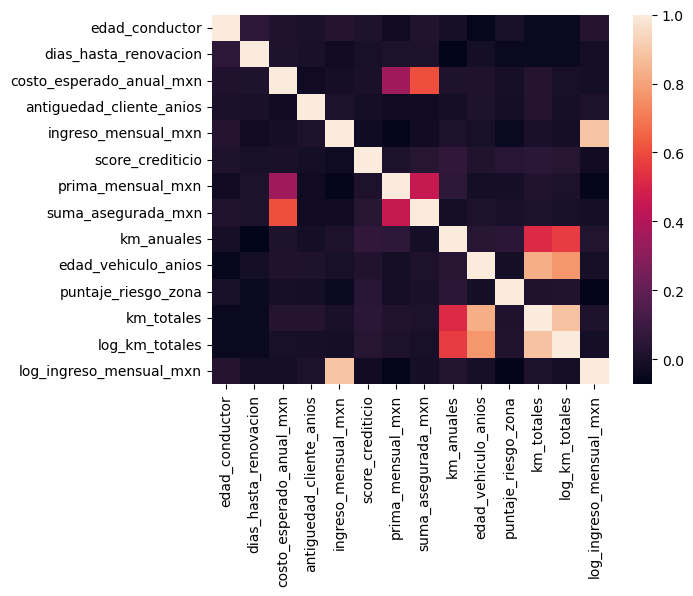

In [533]:
sns.heatmap(data[numerico].corr(numeric_only= True, method = 'pearson'))

In [534]:

## Las variables que se usaran serán la prima y la suma asegurada

# Se verificara que estas no sean multicolineales, mediante el Indice de Condcion
# de su mtz de diseño, método aprendido en econometría:

print (data[['prima_mensual_mxn','suma_asegurada_mxn']].corr())

mtz = data[['prima_mensual_mxn','suma_asegurada_mxn']]

print( np.linalg.matrix_rank(mtz) < mtz.shape[1])

mtz_s = StandardScaler().fit_transform(mtz)

singular_values = np.linalg.svd(mtz_s, compute_uv = False)
condition_number = singular_values.max() / singular_values.min()

## Asi es como me enseñaron (masomenos)
A = mtz_s.T @ mtz_s
eig_val = np.linalg.eigvals(A)
IC = (eig_val.max() / eig_val.min())**0.5
print(IC)

## El indice de condición en muy pequeño, se dice que hay si es mayor a 10
print(condition_number)




                    prima_mensual_mxn  suma_asegurada_mxn
prima_mensual_mxn            1.000000            0.453295
suma_asegurada_mxn           0.453295            1.000000
False
1.6304232608428673
1.6304232608428693


In [535]:
## Temas obligatorios: 
    # Reescalar al menos dos variables numéricas y explicar cuándo conviene el MinMaxScaler 

# El MinMax scaler no es recomendado cuando hay outliers, ni tampoco la estandarización.
# En este caso se requiere que se use un estandarización robusta, o en su defeto

# Los datos tienen dentro algunos outliers, tambien lo hace la variable objetivo. 


df_numericas = data.copy()
df_numericas = df_numericas[['prima_mensual_mxn','suma_asegurada_mxn','costo_esperado_anual_mxn']+ categorica]

df_numericas.info()


<class 'pandas.DataFrame'>
Index: 1050 entries, 1361 to 691
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   prima_mensual_mxn             1050 non-null   float64
 1   suma_asegurada_mxn            1050 non-null   float64
 2   costo_esperado_anual_mxn      1050 non-null   int64  
 3   sexo                          1050 non-null   str    
 4   estado_civil                  1050 non-null   str    
 5   nivel_estudios                1050 non-null   str    
 6   ocupacion                     987 non-null    str    
 7   zona_residencia               1050 non-null   str    
 8   region                        1050 non-null   str    
 9   tipo_vehiculo                 1050 non-null   str    
 10  uso_vehiculo                  1050 non-null   str    
 11  segmento_marca                1024 non-null   str    
 12  metodo_pago                   1050 non-null   str    
 13  canal_venta      

In [536]:
df_numericas.describe()

,prima_mensual_mxn,suma_asegurada_mxn,costo_esperado_anual_mxn,deducible_pct,historial_siniestros_3_anios,numero_siniestros_12m,riesgo_alto,prima_mayor_a_mediana
count,1050.000000,1.050000e+03,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000
mean,646.751429,3.295202e+05,7158.178095,6.925714,0.456190,0.125714,0.155238,0.494286
std,430.866655,1.919268e+05,6988.220620,3.508427,0.659668,0.342989,0.362304,0.500206
min,350.000000,1.095190e+05,500.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,350.000000,1.951632e+05,3488.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,472.500000,2.763470e+05,5554.500000,5.000000,0.000000,0.000000,0.000000,0.000000
75%,725.000000,3.958578e+05,8875.500000,10.000000,1.000000,0.000000,0.000000,1.000000
max,3348.000000,1.600000e+06,131385.000000,15.000000,3.000000,2.000000,1.000000,1.000000


In [537]:
Outlier_descriptive(data = df_numericas, columna='prima_mensual_mxn')

{'Percentil 99.9': np.float64(2812.492000000002),
 'Media +3 desv. est.': np.float64(1939.351393859541),
 'El upper fence': np.float64(1287.5)}

In [538]:

df_numericas = df_numericas[(data['costo_esperado_anual_mxn'] < Outlier_descriptive(data = df_numericas, columna='costo_esperado_anual_mxn')['Media +3 desv. est.']) 
        & (data['suma_asegurada_mxn'] < Outlier_descriptive(data = df_numericas, columna='suma_asegurada_mxn')['Media +3 desv. est.'])
        & (data['prima_mensual_mxn'] < Outlier_descriptive(data = df_numericas, columna='prima_mensual_mxn')['Media +3 desv. est.'])
        ]

df_numericas.count()

prima_mensual_mxn               1019
suma_asegurada_mxn              1019
costo_esperado_anual_mxn        1019
sexo                            1019
estado_civil                    1019
nivel_estudios                  1019
ocupacion                        962
zona_residencia                 1019
region                          1019
tipo_vehiculo                   1019
uso_vehiculo                    1019
segmento_marca                   994
metodo_pago                     1019
canal_venta                     1019
tiene_gps                       1019
asistencia_vial                 1019
mantenimiento_al_dia             985
clase_costo                     1019
deducible_pct                   1019
historial_siniestros_3_anios    1019
numero_siniestros_12m           1019
riesgo_alto                     1019
prima_mayor_a_mediana           1019
dtype: int64

In [539]:
## Exploración de los datos previamente mediante histogramas y boxplor
interact(
    histograma_plotly,
    data = fixed(df_numericas),
    variable_num = Dropdown(options = ['prima_mensual_mxn','suma_asegurada_mxn','costo_esperado_anual_mxn'],value = 'costo_esperado_anual_mxn', description = 'Numérica'),
    variable_cat = Dropdown(options = categorica, value = 'zona_residencia', description = 'Categoría:'),
    nbins = IntSlider(min = 10, max = 250, step = 1, value = 40, description = 'Intervalos: '),
    por_cateogria = Checkbox(description = 'Categorias', value = True)
)

interactive(children=(Dropdown(description='Numérica', index=2, options=('prima_mensual_mxn', 'suma_asegurada_…

<function __main__.histograma_plotly(data, variable_num, variable_cat, nbins=40, por_cateogria=True)>

In [540]:
x_cat = categorica.copy()
x_num = ['prima_mensual_mxn','suma_asegurada_mxn','costo_esperado_anual_mxn']

y_cat = ['riesgo_alto']
y_num = ['costo_esperado_anual_mxn']

x_cat.remove('riesgo_alto')
x_num.remove('costo_esperado_anual_mxn')



In [ ]:
X = df_numericas[x_num]
y = df_numericas[y_num]
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size= 0.3, random_state= RANDOM_STATE)


## Pipeline 

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

X_train_scaled = num_transformer.fit_transform(X_train)
X_test_scaled = num_transformer.fit_transform(X_test)


In [542]:
Regresion = LinearRegression()

Regresion.fit(X_train_scaled, y_train)


y_hat_Reg = Regresion.predict(X_test_scaled)



In [543]:
print(
    'Error Absoluto Medio :', mean_absolute_error(y_test, y_hat_Reg),
    '\nRaiz del promedio de los cuadrados :', root_mean_squared_error(y_test, y_hat_Reg),
    '\nCoeficiente de determinación :', r2_score(y_test, y_hat_Reg)
)

Error Absoluto Medio : 2496.3446648443623 
Raiz del promedio de los cuadrados : 3676.3325293835733 
Coeficiente de determinación : 0.2771450896828991


In [544]:
LassoReg = Lasso()

LassoReg.fit(X = X_train_scaled, y = y_train)

y_hat_lass =LassoReg.predict(X_test_scaled)

In [545]:
print(
    'Error Absoluto Medio :', mean_absolute_error(y_test, y_hat_lass),
    '\nRaiz del promedio de los cuadrados :', root_mean_squared_error(y_test, y_hat_lass),
    '\nCoeficiente de determinación :', r2_score(y_test, y_hat_lass)
)

Error Absoluto Medio : 2496.2595307241695 
Raiz del promedio de los cuadrados : 3676.1894762859065 
Coeficiente de determinación : 0.2772013439098405


In [546]:
y_hat_lass
y_test

,costo_esperado_anual_mxn
480,6631
264,1608
462,13175
1025,7110
1285,3609
...,...
317,8120
373,5170
390,4827
1466,3863


In [547]:
X = df_numericas[x_num + x_cat]
y = [y_cat + y_num]